### imports

In [1]:
import os
from pathlib import Path

import arviz as az
import bambi as bmb
import joblib
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import scipy.optimize
import scipy.spatial.distance
import seaborn as sns
import xarray as xr
from matplotlib.colors import LogNorm, Normalize
from matplotlib.lines import Line2D
from scipy import stats
from scipy.optimize import nnls
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from statsmodels.stats.multitest import multipletests

# Make MPL files saveable.
mpl.rcParams['svg.fonttype'] = 'none'

from src.analysis import compute_nested_correlation_df, load_model_rdms, load_subject_rdms
from src.visualization import plot_image_series, plot_rdm, plot_training_history

np.random.seed(42)  # Reproducibility.

sns.set_theme(style="white")  # "ticks" is also an option.

### plotting style settings

In [2]:
# General Matplotlib settings
mpl.rcParams.update({
    # Typography
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,

    # SVG and PDF editability
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # Line and tick widths
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.major.size": 4,
    "ytick.major.size": 4,

    # Export settings
    "savefig.dpi": 600,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
    "savefig.transparent": False,
})

# Set the general Seaborn plotting style.
sns.set_theme(
    style="white",
    context="paper"
)

# Desired plotting order.
order = [
    "Contrastive global",
    "Contrastive local",
    "Predictive global",
    "Predictive local",
    "Supervised",
    "Supervised shuffled",
    "Untrained",
]

# Base palette.
c = sns.color_palette()


def mute(color, strength=0.4):
    """Create a paler version of a color."""
    gray = 0.75
    return tuple(
        gray + strength * (c - gray)
        for c in color
    )


# Publication colors: focal conditions stay saturated and controls become pale.
condition_colors = {
    "Contrastive global": mute(c[1]),
    "Contrastive local": mute(tuple(i * 0.6 for i in c[1])),
    "Predictive global": mute(c[2]),
    "Predictive local": tuple(i * 0.6 for i in c[2]),
    "Supervised": c[3],
    "Supervised shuffled": mute(
        tuple((a+b)/2 for a, b in zip(c[4], c[3]))
    ),
    "Untrained": mute(c[4]),
}

### Parameters, definitions and paths

In [3]:
# Define the path to our data.
data_dir = "/scratch/guetlid95/datasets/mcdermott_2024/"

# Define subpaths from that.
subject_dir = os.path.join(data_dir, "recordings")
model_dir = os.path.join(data_dir, "models_isi")

# Define the lists over which we iterate.
subjects = sorted([i for i in os.listdir(subject_dir) if "sub" in i])
model_conditions = [
    "Untrained",
    "Supervised",
    "Predictive global",
    "Predictive local",
    "Contrastive global",
    "Contrastive local",
    "Supervised shuffled",
]

# RDM categories in the correct order.
category_names = ['barn', 'beach', 'cave', 'library', 'restaurant', 'castle', 'church', 'conference_room', 'forest']

# Update for valid/invalid setting.
rdm_dict = {
    'valid_church': ('barn_church_valid', 'beach_church_valid'),
    'valid_confroom': ('library_confroom_valid', 'restaurant_confroom_valid'),
    'invalid_confroom': ('barn_confroom_invalid', 'beach_confroom_invalid'),
    'invalid_church': ('library_church_invalid', 'restaurant_church_invalid'),
    'control_castle': ('cave_castle_control',),
    'control_forest': ('cave_forest_control',),
}

category_names = list(rdm_dict.keys())

### H1: Load data

In [4]:
# Load model RDMs.
model_rdm_df = load_model_rdms(model_conditions, model_dir, layer="layerall", series="valid_invalid")

# Load subject RDMs for each half.
subject_rdm_df_1 = load_subject_rdms(subjects, subject_dir, split="ac_fi_block1")
subject_rdm_df_2 = load_subject_rdms(subjects, subject_dir, split="ac_fi_block2")

# Compute model-subject correlations for each half.
correlation_df_1 = compute_nested_correlation_df(model_rdm_df, subject_rdm_df_1, corr_measure=scipy.stats.spearmanr)
correlation_df_2 = compute_nested_correlation_df(model_rdm_df, subject_rdm_df_2, corr_measure=scipy.stats.spearmanr)

# Concatenate correlations across the two halves.
h1_correlation_df = pd.concat([correlation_df_1, correlation_df_2], keys=["First half", "Second half"], names=["split"])

### H1: Preprocess data

In [5]:
# Select the time after the trailing image onset.
h1_df = h1_correlation_df.query("0.6 <= time")

# Average over axes.
h1_df = h1_df.reset_index().groupby(['model', 'split', 'sub'])['correlation'].mean().reset_index()

# Reorder model categories, using Untrained as the baseline.
h1_df["model"] = h1_df["model"].astype("category").cat.reorder_categories(
    ["Untrained", "Supervised shuffled", "Supervised", "Predictive local", "Predictive global",
     "Contrastive local", "Contrastive global",], ordered=True)

# Display the resulting DataFrame.
h1_df

,model,split,sub,correlation
0,Contrastive global,First half,sub01,-0.003924
1,Contrastive global,First half,sub02,0.148614
2,Contrastive global,First half,sub03,0.047229
3,Contrastive global,First half,sub04,0.096967
4,Contrastive global,First half,sub05,0.013233
...,...,...,...,...
415,Untrained,Second half,sub27,0.048719
416,Untrained,Second half,sub28,0.002110
417,Untrained,Second half,sub29,-0.113305
418,Untrained,Second half,sub30,0.074457


### H1: Bayesian model selection

In [6]:
# Collect posteriors by split.
all_posteriors = {}

for split_value in ["First half", "Second half"]:
    # Select data for the current split.
    df_split = h1_df[h1_df["split"] == split_value]

    # Fit the hierarchical model.
    model = bmb.Model("correlation ~ 0 + model + (1|sub)", data=df_split)
    results = model.fit()

    # Extract posterior draws for each model condition.
    posterior = xr.concat(
        [results.posterior["model"].sel(model_dim=l) for l in model_conditions],
        dim="condition"
    ).assign_coords(condition=model_conditions)

    # Save the full posterior object for plotting later.
    all_posteriors[split_value] = posterior

    # Calculate P(best) for each model condition.
    best_model_idx = posterior.argmax("condition")
    prob_best = [(best_model_idx == i).mean().item() for i in range(len(model_conditions))]

    print(f"\nSplit {split_value}")
    for model_name, prob in zip(model_conditions, prob_best):
        print(f"{model_name}: P(best) = {prob:.3f}")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, model, 1|sub_sigma, 1|sub_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.



Split First half
Untrained: P(best) = 0.000
Supervised: P(best) = 0.936
Predictive global: P(best) = 0.000
Predictive local: P(best) = 0.064
Contrastive global: P(best) = 0.000
Contrastive local: P(best) = 0.000
Supervised shuffled: P(best) = 0.000


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, model, 1|sub_sigma, 1|sub_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.



Split Second half
Untrained: P(best) = 0.001
Supervised: P(best) = 0.129
Predictive global: P(best) = 0.005
Predictive local: P(best) = 0.776
Contrastive global: P(best) = 0.015
Contrastive local: P(best) = 0.014
Supervised shuffled: P(best) = 0.060


### H1: print results

In [7]:
# Keep only the selected models for this interaction.
h1_inter_df = h1_df[h1_df["model"].isin(["Supervised", "Predictive local"])].copy()
h1_inter_df["model"] = h1_inter_df["model"].cat.remove_unused_categories()

# Define the Bayesian mixed-effects model.
model_formula = "correlation ~ model * split + (1|sub)"
bayes_model = bmb.Model(model_formula, h1_inter_df, family="gaussian")

# Fit the model and retain the log likelihood.
results = bayes_model.fit(
    draws=3000,
    chains=4,
    cores=4,
    target_accept=0.95,
    idata_kwargs={"log_likelihood": True},
)

summary_example1_direct = az.summary(results, hdi_prob=0.95)
print("Available parameter names:")
print(summary_example1_direct[:7])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, model, split, model:split, 1|sub_sigma, 1|sub_offset]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 10 seconds.


Available parameter names:
                                             mean     sd  hdi_2.5%  hdi_97.5%  \
sigma                                       0.081  0.006     0.070      0.094   
Intercept                                   0.087  0.019     0.050      0.126   
model[Predictive local]                    -0.021  0.021    -0.062      0.020   
split[Second half]                         -0.065  0.021    -0.107     -0.024   
model:split[Predictive local, Second half]  0.032  0.030    -0.025      0.091   
1|sub_sigma                                 0.066  0.013     0.042      0.092   
1|sub[sub01]                                0.126  0.039     0.053      0.205   

                                            mcse_mean  mcse_sd  ess_bulk  \
sigma                                             0.0      0.0    9456.0   
Intercept                                         0.0      0.0    5754.0   
model[Predictive local]                           0.0      0.0    8629.0   
split[Second half]  

### H1: Interaction effect

In [8]:
# Select interaction coefficient
posterior_samples = results.posterior["model:split"].sel(
    {"model:split_dim": "Predictive local, Second half"}
)

# Posterior mean
mean_val = float(posterior_samples.mean())

# HDI
hdi = az.hdi(posterior_samples, hdi_prob=0.95)
hdi_da = hdi["model:split"]

hdi_low = float(hdi_da.sel(hdi="lower").values)
hdi_high = float(hdi_da.sel(hdi="higher").values)

# Posterior probability > 0
p_gt_0 = float((posterior_samples > 0).mean())

# Approximate Bayes Factor (assuming equal prior odds)
bf10 = p_gt_0 / (1 - p_gt_0)

# Evidence interpretation (Jeffreys-style conventions)
evidence_thresholds = {
    1: "evidence for null",
    3: "anecdotal evidence",
    10: "moderate evidence",
    30: "strong evidence",
    100: "very strong evidence",
    float("inf"): "extreme evidence",
}

# get label
evidence = next(
    label for threshold, label in evidence_thresholds.items()
    if bf10 < threshold
)

print(
    f"'Predictive local × Second half' shows {evidence} "
    f"(BF10={bf10:.2f}); "
    f"effect mean={mean_val:.4f}, "
    f"95% HDI=[{hdi_low:.4f}, {hdi_high:.4f}], "
    f"P(>0)={p_gt_0:.3f}. "
)

'Predictive local × Second half' shows moderate evidence (BF10=6.41); effect mean=0.0325, 95% HDI=[-0.0254, 0.0906], P(>0)=0.865. 


### H1: summarize effect

In [9]:
def summarize_effect(posterior_samples, label, favor_negative=False):
    """Summarize the posterior mean, 95% HDI, and directional BF10."""
    mean_val = float(posterior_samples.mean())

    hdi = az.hdi(posterior_samples, hdi_prob=0.95)
    var_name = posterior_samples.name
    hdi_da = hdi[var_name]
    hdi_low = float(hdi_da.sel(hdi="lower").values)
    hdi_high = float(hdi_da.sel(hdi="higher").values)

    p_gt_0 = float((posterior_samples > 0).mean())
    p_relevant = (1 - p_gt_0) if favor_negative else p_gt_0

    # Bound probabilities away from 0 and 1 to avoid division by zero.
    eps = 1e-6
    p_relevant = min(max(p_relevant, eps), 1 - eps)
    bf10 = p_relevant / (1 - p_relevant)

    evidence_thresholds = {
        1: "evidence for null",
        3: "anecdotal evidence",
        10: "moderate evidence",
        30: "strong evidence",
        100: "very strong evidence",
        float("inf"): "extreme evidence",
    }
    evidence = next(l for t, l in evidence_thresholds.items() if bf10 < t)

    print(
        f"'{label}' shows {evidence} "
        f"(BF10={bf10:.2f}); "
        f"effect mean={mean_val:.4f}, "
        f"95% HDI=[{hdi_low:.4f}, {hdi_high:.4f}], "
        f"P({'<' if favor_negative else '>'}0)={p_relevant:.3f}. "
    )
    return bf10, mean_val, hdi_low, hdi_high, p_relevant


# Main effect: model type (Predictive Local vs. Supervised baseline).
posterior_model = results.posterior["model"].sel({"model_dim": "Predictive local"})
summarize_effect(
    posterior_model,
    "Model type (Supervised > Predictive local)",
    favor_negative=True,
)

# Main effect: learning stage (Second half vs. First half baseline).
posterior_stage = results.posterior["split"].sel({"split_dim": "Second half"})
summarize_effect(posterior_stage, "Learning stage (Second half)", favor_negative=False)

# Interaction: Predictive Local × Second half.
posterior_interaction = results.posterior["model:split"].sel(
    {"model:split_dim": "Predictive local, Second half"}
)
summarize_effect(posterior_interaction, "Model × Stage interaction", favor_negative=False)

'Model type (Supervised > Predictive local)' shows moderate evidence (BF10=5.29); effect mean=-0.0209, 95% HDI=[-0.0621, 0.0195], P(<0)=0.841. 
'Learning stage (Second half)' shows evidence for null (BF10=0.00); effect mean=-0.0646, 95% HDI=[-0.1068, -0.0243], P(>0)=0.001. 
'Model × Stage interaction' shows moderate evidence (BF10=6.41); effect mean=0.0325, 95% HDI=[-0.0254, 0.0906], P(>0)=0.865. 


(6.4074074074074066,
 0.03247733297923884,
 -0.025365794429254754,
 0.09064646635625108,
 0.865)

### H1: plot

/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/725744624.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/725744624.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, ha="right", rotation_mode="anchor")
/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/725744624.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/725744624.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks(

Saved SVG to: /scratch/guetlid95/results/repr_pcn_2025/plots/posterior_violin_plot_horizontal.svg
Saved PNG to: /scratch/guetlid95/results/repr_pcn_2025/plots/posterior_violin_plot_horizontal.png


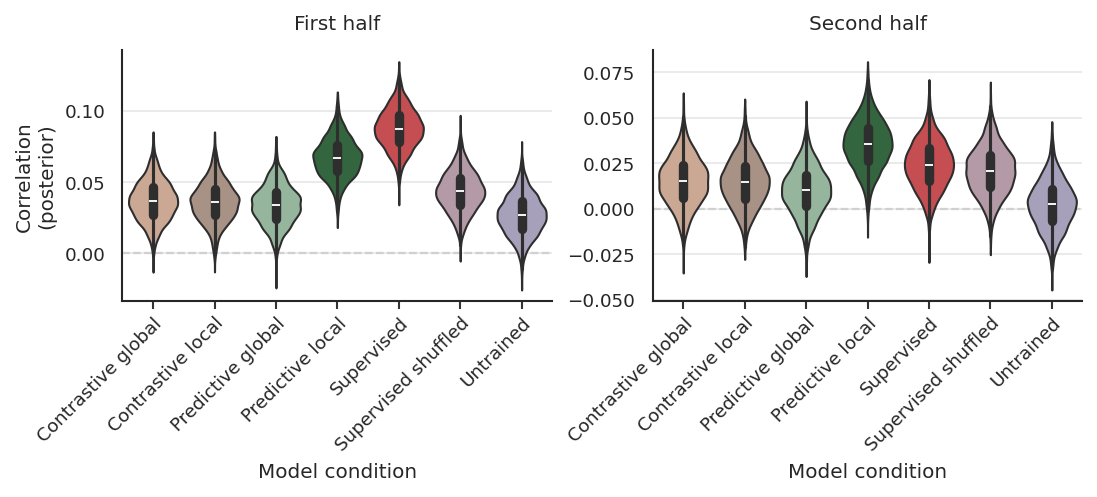

In [10]:
# Figure layout: double-column publication width.
fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), sharey=False, constrained_layout=True)

# Plot each data split in its own panel.
for ax, split_value in zip(axes, ["First half", "Second half"]):
    post = all_posteriors[split_value]

    posterior_df = (
        post.to_dataframe()
        .reset_index()[["model_dim", "model"]]
        .rename(columns={"model_dim": "condition", "model": "correlation"})
    )

    posterior_df = posterior_df[posterior_df["condition"].isin(order)]

    sns.violinplot(
        data=posterior_df,
        x="condition",
        y="correlation",
        inner="box",
        linewidth=1.0,
        cut=0,
        saturation=1,
        palette=condition_colors,
        order=order,
        ax=ax
    )

    # Add a zero reference line.
    ax.axhline(0, color="0.4", lw=1.0, ls="--", zorder=0)

    # Set panel title and axis labels.
    ax.set_title(split_value, pad=10)
    ax.set_xlabel("Model condition")

    if ax is axes[0]:
        ax.set_ylabel("Correlation\n(posterior)")
    else:
        ax.set_ylabel("")

    # Format x-axis ticks for readability.
    ax.tick_params(
        axis="x",
        which="major",
        bottom=True,
        length=4,
        width=1.0,
        color="0.2",
        direction="out",
        pad=2,
        labelrotation=45,
    )

    labels = [t.get_text() for t in ax.get_xticklabels()]

    ax.set_xticklabels(labels, ha="right", rotation_mode="anchor")

    # Add a subtle horizontal grid and remove top/right spines.
    ax.grid(axis="y", color="0.9", linewidth=0.8)
    sns.despine(ax=ax)

# Save the figure in SVG and high-resolution PNG formats.
save_dir = Path("/scratch/guetlid95/results/repr_pcn_2025/plots")
save_dir.mkdir(parents=True, exist_ok=True)

svg_path = save_dir / "posterior_violin_plot_horizontal.svg"
png_path = save_dir / "posterior_violin_plot_horizontal.png"

fig.savefig(svg_path)
fig.savefig(png_path, dpi=600)

print(f"Saved SVG to: {svg_path}")
print(f"Saved PNG to: {png_path}")

plt.show()

## H2: Residual correlation

In [11]:
class NNLSRegression:
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept

    def fit(self, X, y):
        if self.fit_intercept:
            n = X.shape[0]
            X_aug = np.hstack([X, np.ones((n, 1)), -np.ones((n, 1))])
            coef_aug, _ = scipy.optimize.nnls(X_aug, y)
            self.coef_ = coef_aug[:-2]
            self.intercept_ = coef_aug[-2] - coef_aug[-1]
        else:
            self.coef_, _ = scipy.optimize.nnls(X, y)
            self.intercept_ = 0.0
        return self

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        return r2_score(y, self.predict(X))


def calculate_residual_correlation(model_rdm_df, subject_rdm_df, reference_models, method="pearson"):
    """Regress reference models out of model RDMs and correlate residuals with subject RDMs.

    Parameters
    ----------
    model_rdm_df : DataFrame
        MultiIndex (model, step), columns = features.
    subject_rdm_df : DataFrame
        MultiIndex (sub, time), columns = features.
    reference_models : list[str]
        Names of models used as regressors for residualization.
    method : {"pearson", "spearman"}
        Correlation method.

    Returns
    -------
    DataFrame
        Index (model, step, sub, time) with column "residual_correlation".
    """
    regression = NNLSRegression()

    models = model_rdm_df.index.get_level_values("model").unique()
    steps = model_rdm_df.index.get_level_values("step").unique()
    subs = subject_rdm_df.index.get_level_values("sub").unique()
    times = subject_rdm_df.index.get_level_values("time").unique()

    results = []

    for step in steps:
        step_data = model_rdm_df.xs(step, level="step")

        # Build the reference model matrix with one column per reference model.
        X_ref = step_data.loc[reference_models].values.T

        for cur_model in models:
            x = step_data.loc[cur_model].values

            # Remove the variance explained by the reference models.
            x_hat = regression.fit(X_ref, x).predict(X_ref)
            x_res = x - x_hat

            for sub in subs:
                for time in times:
                    y = subject_rdm_df.loc[(sub, time)].values

                    if method == "pearson":
                        r = np.corrcoef(x_res, y)[0, 1]
                    elif method == "spearman":
                        r = spearmanr(x_res, y).correlation
                    else:
                        raise ValueError("method must be 'pearson' or 'spearman'")

                    results.append({
                        "model": cur_model,
                        "step": step,
                        "sub": sub,
                        "time": time,
                        "residual_correlation": r
                    })

    return pd.DataFrame(results).set_index(["model", "step", "sub", "time"])


res_var_df = calculate_residual_correlation(
    model_rdm_df,
    subject_rdm_df_2,
    reference_models=["Supervised", "Supervised shuffled", "Untrained"]
)

/home/guetlid95/.conda/envs/stats/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/guetlid95/.conda/envs/stats/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### H2: calculate correlation CI

In [12]:
def correlation_ci_above_zero(df, alpha=0.01, correction=None):
    """Test whether correlations are significantly above zero across subjects."""
    # Reshape to (n_sub, n_combinations).
    pivoted = df.reset_index().pivot_table(
        index='sub', columns=['model', 'step', 'time'], values=df.columns[0]
    )

    data = pivoted.to_numpy()
    n_sub = data.shape[0]

    # Compute confidence intervals using the Fisher z-transform.
    z = np.arctanh(np.clip(data, -0.9999, 0.9999))
    z_mean = z.mean(axis=0)
    z_se = z.std(axis=0) / np.sqrt(n_sub)

    z_crit = stats.norm.ppf(1 - alpha / 2)

    r_mean = np.tanh(z_mean)
    r_lo = np.tanh(z_mean - z_crit * z_se)
    r_hi = np.tanh(z_mean + z_crit * z_se)

    above_zero = r_lo > 0

    # Compute one-sided p-values for correlations above zero.
    p_uncorrected = stats.norm.cdf(0, loc=z_mean, scale=z_se)

    # Apply the requested multiple-comparison correction.
    if correction is None:
        p_corrected = p_uncorrected
        sig_corrected = p_corrected < alpha
    elif correction.lower() == "bonferroni":
        m = len(p_uncorrected)
        p_corrected = np.minimum(p_uncorrected * m, 1.0)
        sig_corrected = p_corrected < alpha
    elif correction.lower() == "fdr":
        sig_corrected, p_corrected, _, _ = multipletests(
            p_uncorrected, alpha=alpha, method="fdr_bh"
        )
    else:
        raise ValueError("correction must be None, 'bonferroni', or 'fdr'")

    return pd.DataFrame({
        'r_mean': r_mean,
        'r_lo': r_lo,
        'r_hi': r_hi,
        'above_zero': above_zero,
        'p_uncorrected': p_uncorrected,
        'p_corrected': p_corrected,
        'sig_corrected': sig_corrected
    }, index=pivoted.columns)

### H2: plot correlation map


[DEBUG]
steps (first 5): [0 1 2 3 4]
times (first 5): [-0.1  -0.09 -0.08 -0.07 -0.06]
x = time, y = step


/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/2412732303.py:160: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)



Saved SVG to: /scratch/guetlid95/results/repr_pcn_2025/plots/residual_correlation_time_step.svg
Saved PNG to: /scratch/guetlid95/results/repr_pcn_2025/plots/residual_correlation_time_step.png


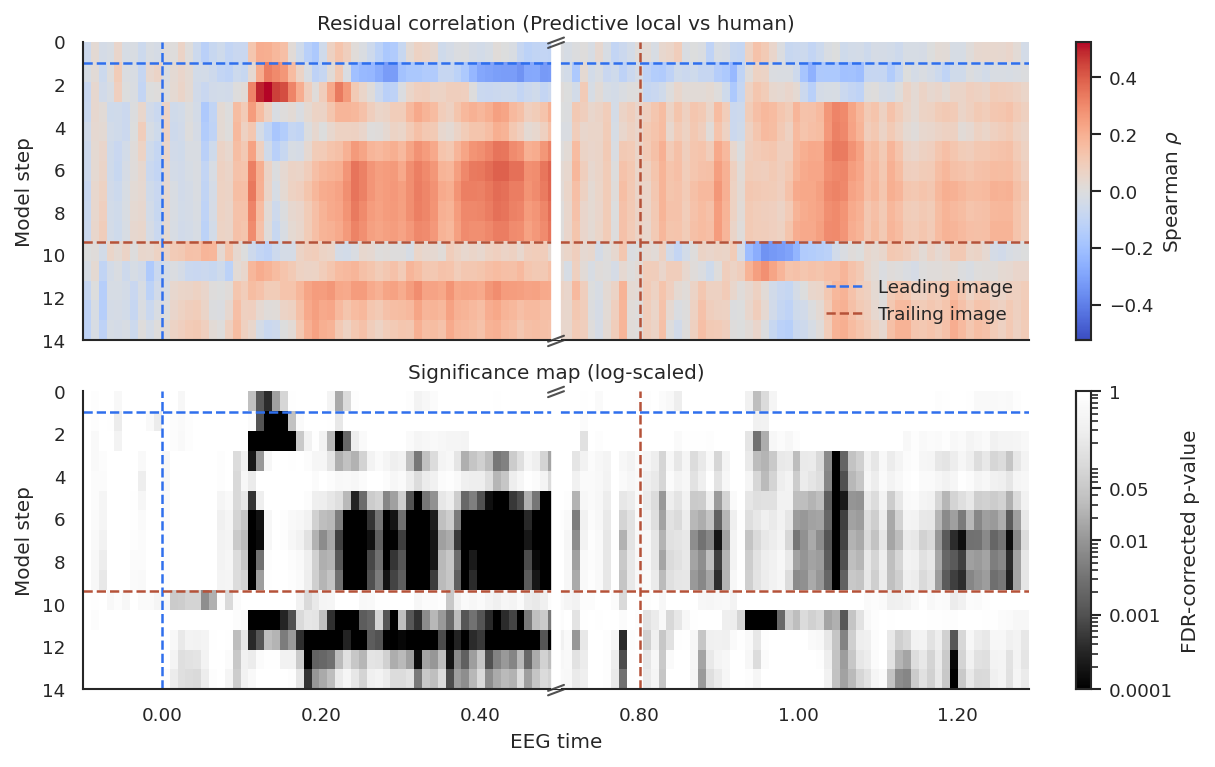

In [13]:
sns.set_theme(style="white", context="paper")

# Data
res = correlation_ci_above_zero(res_var_df, correction="fdr")

r_df = res["r_mean"].loc["Predictive local"].unstack("time")
p_df = res["p_corrected"].loc["Predictive local"].unstack("time")

r_df = r_df.sort_index().sort_index(axis=1)
p_df = p_df.sort_index().sort_index(axis=1)

r = r_df.to_numpy()
p = np.clip(p_df.to_numpy(), 1e-20, 1)

steps = r_df.index.to_numpy()
times = r_df.columns.to_numpy()

# Debug information.
print("\n[DEBUG]")
print("steps (first 5):", steps[:5])
print("times (first 5):", times[:5])
print("x = time, y = step")

# Create grid edges for the heatmaps.
time_edges = np.linspace(times.min(), times.max(), len(times) + 1)
step_edges = np.linspace(steps.min(), steps.max(), len(steps) + 1)

# Define the x-axis gap.
gap_start = 0.49
gap_end = 0.5
break_x = (gap_start + gap_end) / 2


def add_axis_break(ax, x, size=0.010, color="0.2"):
    """Add a subtle axis break marker."""
    trans = ax.get_xaxis_transform()

    for y0 in [0, 1]:  # Bottom and top.
        ax.plot(
            [x - size, x + size],
            [y0 - size - 0.01, y0 + size - 0.01],
            transform=trans,
            color=color,
            lw=1.0,
            alpha=0.85,
            clip_on=False,
            zorder=20,
        )
        ax.plot(
            [x - size, x + size],
            [y0 + 0.015 - size - 0.01, y0 + 0.015 + size - 0.01],
            transform=trans,
            color=color,
            lw=1.0,
            alpha=0.85,
            clip_on=False,
            zorder=20,
        )


# Create the correlation and significance plots.
fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 5),
    sharex=True,
    constrained_layout=True,
)

# Top: correlation.
im0 = axes[0].pcolormesh(
    time_edges,
    step_edges,
    r,
    cmap="coolwarm",
    shading="auto",
    vmin=-np.max(np.abs(r)),
    vmax=np.max(np.abs(r)),
)

cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label(r"Spearman $\rho$")

axes[0].set_title("Residual correlation (Predictive local vs human)")
axes[0].set_ylabel("Model step")

# Mark leading and trailing events.
leading_step = 1.
trailing_step = 9.4
leading_time = 0.0
trailing_time = 0.6

event_style = dict(ls="--", lw=1.2)

leading_color = "#2F6FED"
trailing_color = "#B55239"

axes[0].axhline(leading_step, color=leading_color, **event_style)
axes[0].axvline(leading_time, color=leading_color, **event_style)

axes[0].axhline(trailing_step, color=trailing_color, **event_style)
axes[0].axvline(trailing_time, color=trailing_color, **event_style)

axes[0].legend(
    handles=[
        Line2D([0], [0], color=leading_color, lw=1.2, ls="--", label="Leading image"),
        Line2D([0], [0], color=trailing_color, lw=1.2, ls="--", label="Trailing image"),
    ],
    loc="lower right",
    frameon=False,
)
axes[0].axvspan(gap_start, gap_end, color="white", alpha=1.0, zorder=5)

# Bottom: significance.
im1 = axes[1].pcolormesh(
    time_edges,
    step_edges,
    p,
    cmap=plt.cm.Greys_r,
    norm=LogNorm(vmin=1e-4, vmax=1),
    shading="auto",
)

cbar1 = fig.colorbar(im1, ax=axes[1])
cbar1.set_label("FDR-corrected p-value")
cbar1.set_ticks([1, 0.05, 0.01, 0.001, 0.0001])
cbar1.set_ticklabels(["1", "0.05", "0.01", "0.001", "0.0001"])

axes[1].set_title("Significance map (log-scaled)")
axes[1].set_xlabel("EEG time")
axes[1].set_ylabel("Model step")

axes[1].axhline(leading_step, color=leading_color, **event_style)
axes[1].axvline(leading_time, color=leading_color, **event_style)

axes[1].axhline(trailing_step, color=trailing_color, **event_style)
axes[1].axvline(trailing_time, color=trailing_color, **event_style)

axes[1].axvspan(gap_start, gap_end, color="white", alpha=1.0, zorder=5)

# Keep the model step orientation consistent across both panels.
axes[0].invert_yaxis()
axes[1].invert_yaxis()

# Add axis break markers.
add_axis_break(axes[0], break_x)
add_axis_break(axes[1], break_x)


def shift_right_ticks(ax, shift=0.2):
    ticks = ax.get_xticks()
    labels = []

    for t in ticks:
        if t >= gap_end:
            labels.append(f"{t + shift:.2f}")
        else:
            labels.append(f"{t:.2f}")

    ax.set_xticklabels(labels)


# Shift labels on the right half of the x-axis.
shift_right_ticks(axes[1])

# Final plot styling.
axes[0].tick_params(axis="x", labelbottom=False)
sns.despine(fig=fig)

# Save the figure in SVG and PNG formats.
save_dir = Path("/scratch/guetlid95/results/repr_pcn_2025/plots")
save_dir.mkdir(parents=True, exist_ok=True)

svg_path = save_dir / "residual_correlation_time_step.svg"
png_path = save_dir / "residual_correlation_time_step.png"

fig.savefig(svg_path, format="svg")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

print(f"\nSaved SVG to: {svg_path}")
print(f"Saved PNG to: {png_path}")

plt.show()

### H2: print templates

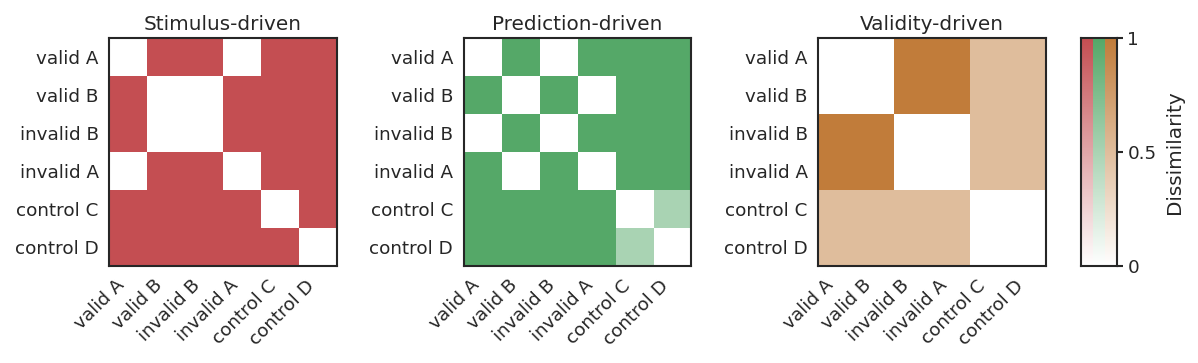

In [10]:
sns.set_theme(style="white", context="paper")

# Define data.
category_names = ["valid A", "valid B", "invalid B", "invalid A", "control C", "control D"]

abstract_stimulus_driven = np.array([
    [0, 1, 1, 0, 1, 1],
    [1, 0, 0, 1, 1, 1],
    [1, 0, 0, 1, 1, 1],
    [0, 1, 1, 0, 1, 1],
    [1, 1, 1, 1, 0, 1],
    [1, 1, 1, 1, 1, 0]
])
abstract_validity_driven = np.array([
    [0, 0, 1, 1, 0.5, 0.5],
    [0, 0, 1, 1, 0.5, 0.5],
    [1, 1, 0, 0, 0.5, 0.5],
    [1, 1, 0, 0, 0.5, 0.5],
    [0.5, 0.5, 0.5, 0.5, 0, 0],
    [0.5, 0.5, 0.5, 0.5, 0, 0]
])
abstract_prediction_driven = np.array([
    [0, 1, 0, 1, 1, 1],
    [1, 0, 1, 0, 1, 1],
    [0, 1, 0, 1, 1, 1],
    [1, 0, 1, 0, 1, 1],
    [1, 1, 1, 1, 0, 0.5],
    [1, 1, 1, 1, 0.5, 0]
])

# Define Colormaps.
model_colors = {
    "Stimulus-driven": "#C44E52",
    "Prediction-driven": "#55A868",
    "Validity-driven": "#C17C3A",
}
def make_cmap(hex_color):
    return mcolors.LinearSegmentedColormap.from_list("", ["white", hex_color])
cmaps = {k: make_cmap(v) for k, v in model_colors.items()}

# Create the figure and shared colorbar axes.
fig = plt.figure(figsize=(9.5, 3))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.18], wspace=0.7)
axes = [fig.add_subplot(gs[i]) for i in range(3)]

# Create RDM dict
rdms = [
    ("Stimulus-driven", abstract_stimulus_driven),
    ("Prediction-driven", abstract_prediction_driven),
    ("Validity-driven", abstract_validity_driven),
]


def plot_rdm(ax, matrix, title, cmap):
    """Plot a single representational dissimilarity matrix."""
    ax.imshow(matrix, cmap=cmap, vmin=0, vmax=1, interpolation="nearest", aspect="equal")

    ax.set_title(title, pad=4)
    ax.set_xticks(range(len(category_names)))
    ax.set_yticks(range(len(category_names)))
    ax.set_xticklabels(category_names, rotation=45, ha="right")
    ax.set_yticklabels(category_names)
    ax.tick_params(length=3, width=1, pad=2)

    for spine in ax.spines.values():
        spine.set_linewidth(1)


for ax, (key, mat) in zip(axes, rdms):
    plot_rdm(ax, mat, key, cmaps[key])

# Draw once so matplotlib finalizes the actual RDM axis positions.
fig.canvas.draw()

rdm_pos = axes[0].get_position()

# Width and gap of the custom colorbar.
cbar_width = 0.025
cbar_gap = 0.025

# Match the colorbar height and vertical position to the RDM axes.
cax = fig.add_axes([
    axes[2].get_position().x1 + cbar_gap,
    rdm_pos.y0,
    cbar_width,
    rdm_pos.height,
])

N = 256

keys = [
    "Stimulus-driven",
    "Prediction-driven",
    "Validity-driven",
]

panel = np.zeros((N, 3, 4))
vals = np.linspace(0, 1, N)

for col_idx, key in enumerate(keys):
    panel[:, col_idx, :] = cmaps[key](vals)

cax.imshow(
    panel[::-1],
    aspect="auto",
    extent=[0, 1, 0, 1],
    interpolation="nearest",
)

cax.set_xlim(0, 1)
cax.set_ylim(0, 1)

# Put the numerical scale on the right side.
cax.yaxis.set_ticks_position("right")
cax.yaxis.set_label_position("right")
cax.set_yticks([0, 0.5, 1])
cax.set_yticklabels(["0", "0.5", "1"])
cax.set_ylabel("Dissimilarity", labelpad=4)
cax.set_xticks([])
cax.tick_params(axis="y", length=3, width=1, pad=2)

for spine in cax.spines.values():
    spine.set_linewidth(1)

save_dir = Path("/scratch/guetlid95/results/repr_pcn_2025/plots")
save_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(save_dir / "rdm_examples.svg", format="svg", bbox_inches="tight")
fig.savefig(save_dir / "rdm_examples.png", dpi=600, bbox_inches="tight")

plt.show()

### H2 calculate residual variance

In [15]:
def r2_nnls(X, y):
    """Compute NNLS R² with an intercept."""
    return NNLSRegression(fit_intercept=True).fit(X, y).score(X, y)


def compute_residual_rdms(model_rdm_df, reference_models):
    """Regress reference models out of each model RDM for each step."""
    models = model_rdm_df.index.get_level_values("model").unique()
    steps = model_rdm_df.index.get_level_values("step").unique()

    rows = {}
    for step in steps:
        step_data = model_rdm_df.xs(step, level="step")
        X_ref = step_data.loc[reference_models].values.T  # (features, n_ref)

        for model in models:
            x = step_data.loc[model].values
            x_hat = NNLSRegression(fit_intercept=True).fit(X_ref, x).predict(X_ref)
            x_res = x - x_hat
            rows[(model, step)] = x_res

    # Reconstruct the residual RDMs with the original index and columns.
    residual_df = pd.DataFrame(
        rows.values(),
        index=pd.MultiIndex.from_tuples(rows.keys(), names=["model", "step"]),
        columns=model_rdm_df.columns,
    )
    return residual_df


def compute_shared_variance(residual_rdm_df, eeg_df, templates):
    """Compute shared variance between residual model RDMs, EEG RDMs, and templates.

    Parameters
    ----------
    residual_rdm_df : DataFrame
        MultiIndex (model, step), columns = RDM features.
    eeg_df : DataFrame
        MultiIndex (sub, time), columns = RDM features.
    templates : dict[str, np.ndarray]
        Flat (squareform) template vectors keyed by template name.
    """
    records = []

    model_grouped = residual_rdm_df.groupby(level=["model", "step"])
    eeg_grouped = eeg_df.groupby(level=["sub", "time"])

    for (model_name, step), model_row in model_grouped:
        m = model_row.values.reshape(-1, 1)  # (n_features, 1)

        for (sub, time), eeg_row in eeg_grouped:
            y = eeg_row.values.flatten()  # (n_features,)
            r2_m = r2_nnls(m, y)

            for tpl_name, tpl_vec in templates.items():
                t = tpl_vec.reshape(-1, 1)
                r2_t = r2_nnls(t, y)
                r2_mt = r2_nnls(np.hstack([m, t]), y)

                records.append({
                    "model": model_name,
                    "step": step,
                    "sub": sub,
                    "time": time,
                    "template": tpl_name,
                    "r2_model": r2_m,
                    "r2_template": r2_t,
                    "r2_full": r2_mt,
                    "shared_var": r2_m + r2_t - r2_mt,
                })

    return pd.DataFrame(records).set_index(["model", "step", "sub", "time", "template"])


templates = {
    "stimulus_driven": scipy.spatial.distance.squareform(abstract_stimulus_driven),
    "validity_driven": scipy.spatial.distance.squareform(abstract_validity_driven),
    "prediction_driven": scipy.spatial.distance.squareform(abstract_prediction_driven),
}

# Residualise the selected model RDMs against the reference models.
residual_rdm_df = compute_residual_rdms(
    model_rdm_df[model_rdm_df.index.get_level_values("model").isin(["Supervised", "Supervised shuffled", "Untrained", "Predictive local"])],
    reference_models=["Supervised", "Supervised shuffled", "Untrained"],
)

# Keep only the Predictive local residuals for the shared-variance analysis.
residual_rdm_df = residual_rdm_df[residual_rdm_df.index.get_level_values("model").isin(["Predictive local"])]

# Compute shared variance between the residuals and the EEG/template RDMs.
result_df = compute_shared_variance(
    residual_rdm_df,
    eeg_df=subject_rdm_df_2,
    templates=templates,
)

### H2: calculate significance for shared variance

In [16]:
# Define Settings.
value_col = "shared_var"
templates = ["stimulus_driven", "prediction_driven", "validity_driven"]
template_labels = {
    "stimulus_driven": "Stimulus-driven",
    "prediction_driven": "Prediction-driven",
    "validity_driven": "Validity-driven",
}

# Prepare data.
df = result_df.reset_index()
df = df[df["model"] == "Predictive local"]

all_subject_means = []

# Process each template.
for tpl in templates:
    # Select data for the current template.
    tpl_df = df[df["template"] == tpl].copy()

    # Create the step-by-time matrix used for plotting.
    mat = tpl_df.pivot_table(
        index="step", columns="time", values=value_col, aggfunc="mean"
    ).sort_index()

    # Identify significant step/time pairs.
    sig_mask = p < 0.05
    sig_pairs = []

    steps = mat.index.to_numpy()
    times = mat.columns.to_numpy()

    for i, step in enumerate(steps):
        for j, time in enumerate(times):
            if sig_mask[i, j]:
                sig_pairs.append((step, time))

    sig_df = pd.DataFrame(sig_pairs, columns=["step", "time"])

    # Keep only significant cells.
    df_sig = tpl_df.merge(sig_df, on=["step", "time"])

    # Calculate the subject-level mean across significant cells.
    subject_means = (
        df_sig.groupby("sub")[value_col]
        .mean()
        .reset_index(name="mean_r2")
    )

    subject_means["template"] = template_labels[tpl]
    all_subject_means.append(subject_means)

    # Fit the Bayesian model against 0.
    model = bmb.Model("mean_r2 ~ 1", subject_means, family="gaussian")

    results = model.fit(
        draws=3000,
        chains=4,
        cores=4,
        target_accept=0.95,
        progressbar=False,
    )

    posterior = results.posterior["Intercept"]
    p_gt_0 = (posterior > 0).mean().item()

    summary = az.summary(results, hdi_prob=0.95)

    mean_val = summary.loc["Intercept", "mean"]
    hdi_low = summary.loc["Intercept", "hdi_2.5%"]
    hdi_high = summary.loc["Intercept", "hdi_97.5%"]

    differs = (hdi_low > 0) or (hdi_high < 0)

    # Print the Bayesian test result.
    if differs:
        print(
            f"{template_labels[tpl]} in the significant areas "
            f"differs from 0 with P(>0)={p_gt_0:.3f} "
            f"(mean={mean_val:.4f}, "
            f"95% HDI=[{hdi_low:.4f}, {hdi_high:.4f}])"
        )
    else:
        print(
            f"{template_labels[tpl]} in the significant areas "
            f"does NOT credibly differ from 0 "
            f"(P(>0)={p_gt_0:.3f}, "
            f"mean={mean_val:.4f}, "
            f"95% HDI=[{hdi_low:.4f}, {hdi_high:.4f}])"
        )

Initializing NUTS using jitter+adapt_diag...


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept]
Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 3 seconds.
Initializing NUTS using jitter+adapt_diag...


Stimulus-driven in the significant areas does NOT credibly differ from 0 (P(>0)=0.308, mean=-0.0000, 95% HDI=[-0.0020, 0.0010])


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept]
Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 3 seconds.
Initializing NUTS using jitter+adapt_diag...


Prediction-driven in the significant areas differs from 0 with P(>0)=1.000 (mean=0.0180, 95% HDI=[0.0150, 0.0210])


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept]
Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 3 seconds.


Validity-driven in the significant areas does NOT credibly differ from 0 (P(>0)=1.000, mean=0.0010, 95% HDI=[0.0000, 0.0010])


### H2: plot comparisons

/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/414009393.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/414009393.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


Saved SVG to: /scratch/guetlid95/results/repr_pcn_2025/plots/subject_mean_r2_violin_matched_style.svg
Saved PNG to: /scratch/guetlid95/results/repr_pcn_2025/plots/subject_mean_r2_violin_matched_style.png


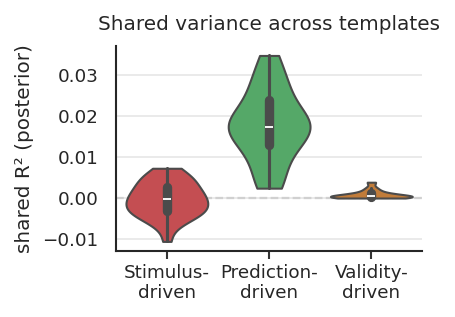

In [17]:
# Prepare data for plotting.
plot_df = pd.concat(all_subject_means, ignore_index=True)

order = ["Stimulus-driven", "Prediction-driven", "Validity-driven"]

plot_df["template"] = pd.Categorical(
    plot_df["template"],
    categories=order,
    ordered=True
)

# Define the template colors.
model_colors = {
    "Stimulus-driven": "#C44E52",
    "Prediction-driven": "#55A868",
    "Validity-driven": "#C17C3A",
}

# Create the figure.
fig, ax = plt.subplots(figsize=(2.8, 2), constrained_layout=True)

# Plot the distribution of subject-level mean R² values.
sns.violinplot(
    data=plot_df,
    x="template",
    y="mean_r2",
    order=order,
    palette=model_colors,
    inner="box",
    cut=0,
    linewidth=1.0,
    saturation=1,
    ax=ax
)

# Add a zero reference line.
ax.axhline(
    0,
    color="0.4",
    linestyle="--",
    linewidth=1.0,
    zorder=0
)

# Set plot labels.
ax.set_title("Shared variance across templates", pad=8)
ax.set_xlabel("")
ax.set_ylabel("shared R² (posterior)")

# Style the x-axis ticks and labels.
ax.tick_params(
    axis="x",
    which="major",
    bottom=True,
    length=4,
    width=1.0,
    color="0.2",
    direction="out",
    pad=2
)

ax.set_xticklabels(
    [t.get_text().replace("-", "-\n") for t in ax.get_xticklabels()],
    rotation=0,
    ha="center"
)

# Add the y-axis grid and remove unnecessary spines.
ax.grid(axis="y", color="0.9", linewidth=0.8)
sns.despine(ax=ax)

# Save the figure in both SVG and PNG formats.
save_dir = Path("/scratch/guetlid95/results/repr_pcn_2025/plots")
save_dir.mkdir(parents=True, exist_ok=True)

svg_path = save_dir / "subject_mean_r2_violin_matched_style.svg"
png_path = save_dir / "subject_mean_r2_violin_matched_style.png"

fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

print(f"Saved SVG to: {svg_path}")
print(f"Saved PNG to: {png_path}")

plt.show()

### H2: plot maps with significance

/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/2433038284.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/2433038284.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/2433038284.py:129: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/localscratch/tmp/guetlid95/tmp.26461768.0/ipykernel_43313/2433038284.py:147: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved SVG: /scratch/guetlid95/results/repr_pcn_2025/plots/residual_shared_variance_heatmaps.svg
Saved PNG: /scratch/guetlid95/results/repr_pcn_2025/plots/residual_shared_variance_heatmaps.png


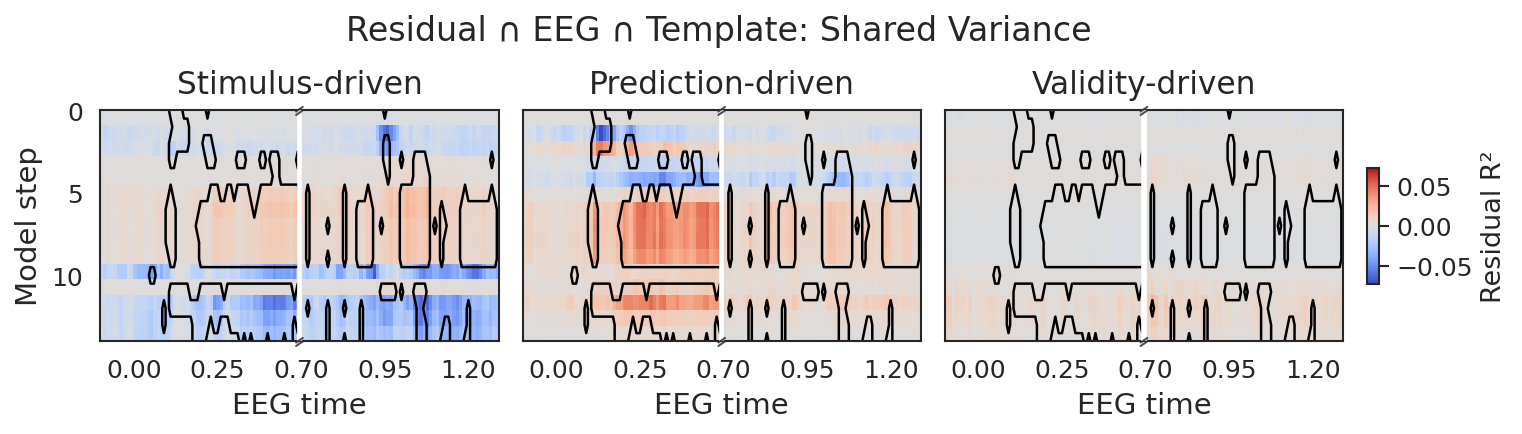

In [18]:
# define settings.
value_col = "shared_var"
templates = ["stimulus_driven", "prediction_driven", "validity_driven"]
template_labels = {
    "stimulus_driven": "Stimulus-driven",
    "prediction_driven": "Prediction-driven",
    "validity_driven": "Validity-driven",
}

df_plot = result_df.reset_index()
df_plot = df_plot[df_plot["model"] == "Predictive local"]

# Prepare all matrices and determine a shared color scale.
all_vals = []
Z_dict = {}

for tpl in templates:
    mat = df_plot[df_plot["template"] == tpl].pivot_table(
        index="step", columns="time", values=value_col, aggfunc="mean"
    ).sort_index()
    Z = mat.copy()
    Z_dict[tpl] = (mat, Z)
    all_vals.append(Z.values)

all_vals = np.concatenate([v.flatten() for v in all_vals])
max_abs = np.nanmax(np.abs(all_vals))
vmin, vmax = -max_abs, max_abs

cmap_base = plt.get_cmap("coolwarm")
norm = Normalize(vmin=vmin, vmax=vmax)
im_mappable = cm.ScalarMappable(norm=norm, cmap=cmap_base)

# Define the gap and its center for the axis-break marker.
gap_start = 0.49
gap_end = 0.5
break_x = (gap_start + gap_end) / 2

# Create the figure and grid layout.
fig = plt.figure(figsize=(11., 2.))
gs = fig.add_gridspec(
    nrows=1,
    ncols=len(templates) + 1,
    width_ratios=[1] * len(templates) + [0.03],
    wspace=0.08,
    hspace=0.15,
)

# Define font sizes.
TITLE_FS = 15
AXIS_LABEL_FS = 14
TICK_FS = 12
CBAR_FS = 13
SUPTITLE_FS = 16


def add_axis_break(ax, x, size=0.010, color="0.2"):
    """Add an axis-break marker at the given x position."""
    trans = ax.get_xaxis_transform()

    for y0 in [0, 1]:
        ax.plot(
            [x - size, x + size],
            [y0 - size - 0.01, y0 + size - 0.01],
            transform=trans,
            color=color,
            lw=1.0,
            alpha=0.85,
            clip_on=False,
            zorder=20,
        )
        ax.plot(
            [x - size, x + size],
            [y0 + 0.015 - size - 0.01, y0 + 0.015 + size - 0.01],
            transform=trans,
            color=color,
            lw=1.0,
            alpha=0.85,
            clip_on=False,
            zorder=20,
        )


# Plot one heatmap for each template.
for j, tpl in enumerate(templates):
    ax = fig.add_subplot(gs[0, j])

    mat, Z = Z_dict[tpl]
    x = mat.columns.values
    y = mat.index.values

    rgba = cmap_base(norm(Z.values)).copy()
    ax.imshow(
        rgba,
        aspect="auto",
        origin="upper",
        extent=[x.min(), x.max(), y.max(), y.min()],
        interpolation="nearest",
    )

    sig_mask = (p < 0.05).astype(float)
    ax.contour(x, y, sig_mask, levels=[0.5], colors="black", linewidths=1.2)

    # Mark the gap in the x-axis.
    ax.axvspan(gap_start, gap_end, color="white", alpha=1.0, zorder=5)

    ax.set_title(f"{template_labels[tpl]}", fontsize=TITLE_FS, pad=8)
    ax.set_xlabel("EEG time", fontsize=AXIS_LABEL_FS)

    if j == 0:
        ax.set_ylabel("Model step", fontsize=AXIS_LABEL_FS)
    else:
        ax.tick_params(labelleft=False)

    ax.tick_params(labelsize=TICK_FS)

    # Add the axis-break marker and shift labels after the gap.
    add_axis_break(ax, break_x)

    def shift_right_ticks(ax, shift=0.2):
        ticks = ax.get_xticks()
        labels = []

        for t in ticks:
            if t >= gap_end:
                labels.append(f"{t + shift:.2f}")
            else:
                labels.append(f"{t:.2f}")

        ax.set_xticklabels(labels)

    shift_right_ticks(ax)

# Add the shared colorbar.
cax = fig.add_subplot(gs[0, -1])
pos = cax.get_position()
new_height = pos.height * 0.5
new_y0 = pos.y0 + (pos.height - new_height) / 2
cax.set_position([pos.x0, new_y0, pos.width, new_height])

cb = fig.colorbar(im_mappable, cax=cax)
cb.set_label("Residual R²", fontsize=CBAR_FS)
cb.ax.tick_params(labelsize=TICK_FS)

# Add the figure title.
fig.suptitle("Residual ∩ EEG ∩ Template: Shared Variance", y=1.2, fontsize=SUPTITLE_FS)

plt.tight_layout()

# Save the figure in SVG and PNG formats.
save_dir = Path("/scratch/guetlid95/results/repr_pcn_2025/plots")
save_dir.mkdir(parents=True, exist_ok=True)

svg_path = save_dir / "residual_shared_variance_heatmaps.svg"
png_path = save_dir / "residual_shared_variance_heatmaps.png"

fig.savefig(svg_path, bbox_inches="tight")
fig.savefig(png_path, dpi=600, bbox_inches="tight")

print(f"Saved SVG: {svg_path}")
print(f"Saved PNG: {png_path}")

plt.show()